# Emotion Detection — MobileNetV2 on FER-2013
**COS30082 — Hasindu**

Driver notebook. All real logic lives in `emotion/src/` (importable Python modules). This notebook just orchestrates and produces the plots / metrics that go into the group report.

**Pipeline:**
1. Mount Drive + clone repo + install deps
2. Download FER-2013 from Kaggle into Drive (once)
3. EDA — class counts, sample grid
4. Build DataLoaders
5. Build model (MobileNetV2, ImageNet pretrained, last 4 blocks unfrozen, new 7-class head)
6. Train with class-weighted cross-entropy, checkpoint every epoch to Drive
7. Evaluate on FER-2013 public test set
8. Smoke-test the `EmotionPredictor` (the only thing the UI teammate needs)

## 1. Setup: Drive, repo, dependencies

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Clone the repo into Colab's ephemeral disk and check out emotion-branch.
# If you already cloned earlier in this session, this cell is safe to re-run.
%cd /content
![ -d COS30082-Facial-Recognition ] || git clone https://github.com/jeromeliao03/COS30082-Facial-Recognition.git
%cd /content/COS30082-Facial-Recognition
!git fetch origin && git checkout emotion-branch && git pull --ff-only

/content
/content/COS30082-Facial-Recognition
Already on 'emotion-branch'
Your branch is up to date with 'origin/emotion-branch'.
Already up to date.


In [18]:
!pip install -q -r emotion/requirements.txt

In [19]:
# Make `from emotion.src...` work from the notebook by adding repo root to path.
import sys, os
REPO_ROOT = '/content/COS30082-Facial-Recognition'
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
print('torch', torch.__version__, '| cuda:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

torch 2.10.0+cu128 | cuda: True | Tesla T4


In [20]:
from google.colab import files
files.upload()  # pick kaggle.json from your laptop
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
# Also persist to Drive so future runs don't need re-upload:
shutil.copy('/root/.kaggle/kaggle.json', '/content/drive/MyDrive/MLGroup/kaggle.json')

Saving kaggle.json to kaggle.json


'/content/drive/MyDrive/MLGroup/kaggle.json'

## 2. Download FER-2013 from Kaggle into Drive (run once)

In [21]:
# Upload your kaggle.json (Settings -> API -> Create New Token) to Drive at
#   /content/drive/MyDrive/MLGroup/kaggle.json   (recommended, one-time setup)
# This cell copies it into ~/.kaggle and downloads FER-2013 if not already present.
import os, shutil, pathlib
from emotion.src import config as C

DATA_DIR = pathlib.Path(C.DATA_DIR)
DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
C.MODELS_DIR.mkdir(parents=True, exist_ok=True)
C.REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / 'train').exists():
    src = '/content/drive/MyDrive/MLGroup/kaggle.json'
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy(src, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    !kaggle datasets download -d msambare/fer2013 -p /content --unzip
    # The Kaggle archive expands to /content/train and /content/test.
    shutil.move('/content/train', str(DATA_DIR / 'train'))
    shutil.move('/content/test',  str(DATA_DIR / 'test'))
    print('Dataset extracted to', DATA_DIR)
else:
    print('Dataset already on Drive:', DATA_DIR)

print('train classes:', sorted(os.listdir(DATA_DIR / 'train')))
print('test  classes:', sorted(os.listdir(DATA_DIR / 'test')))

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 112MB/s]

Dataset extracted to /content/drive/MyDrive/MLGroup/emotion/data/fer2013
train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
test  classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. EDA — class distribution + sample images

{'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}


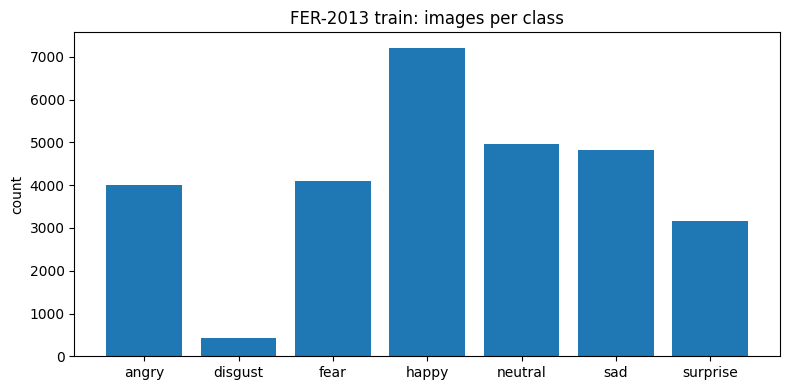

In [22]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image
from emotion.src import config as C

counts = {cls: len(os.listdir(C.TRAIN_DIR / cls)) for cls in C.CLASSES}
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(counts.keys()), list(counts.values()))
ax.set_title('FER-2013 train: images per class')
ax.set_ylabel('count')
fig.tight_layout(); plt.show()
fig.savefig(C.REPORTS_DIR / 'class_distribution.png', dpi=150)

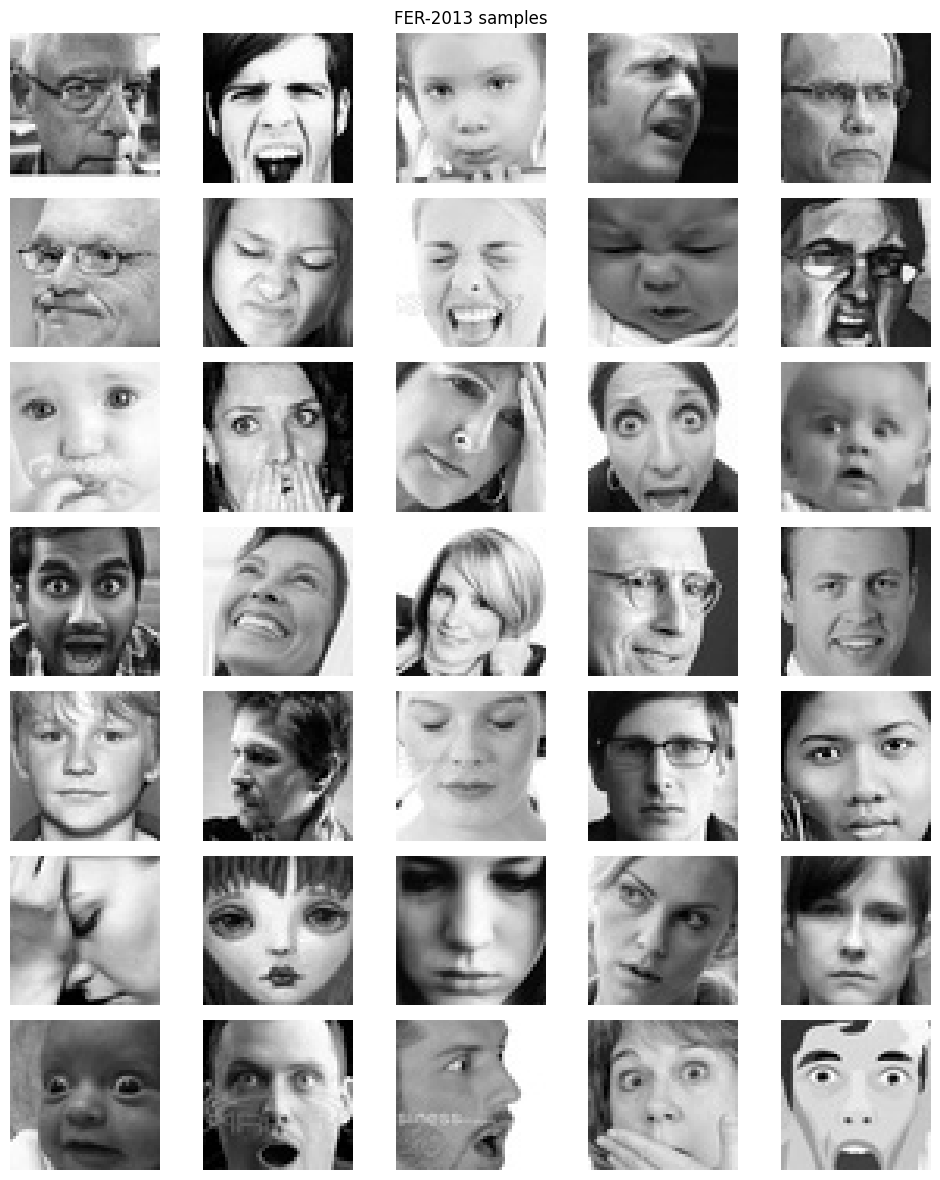

In [23]:
# Sample grid: one row per class, 5 random examples each.
random.seed(0)
fig, axes = plt.subplots(len(C.CLASSES), 5, figsize=(10, 12))
for r, cls in enumerate(C.CLASSES):
    files = os.listdir(C.TRAIN_DIR / cls)
    picks = random.sample(files, 5)
    for c, fn in enumerate(picks):
        img = Image.open(C.TRAIN_DIR / cls / fn)
        axes[r, c].imshow(img, cmap='gray')
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_ylabel(cls, rotation=0, ha='right', va='center')
fig.suptitle('FER-2013 samples'); fig.tight_layout(); plt.show()
fig.savefig(C.REPORTS_DIR / 'sample_grid.png', dpi=150)

**Observation for the report:** `disgust` has ~547 images vs. ~7000 for `happy` — a ~13× imbalance. Mitigated by passing inverse-frequency class weights into `CrossEntropyLoss` (see `data.py` and `train.py`).

## 4. DataLoaders

In [24]:
from emotion.src.data import build_dataloaders
train_loader, val_loader, test_loader, class_weights, train_counts = build_dataloaders()
print('train batches:', len(train_loader), '| val batches:', len(val_loader),
      '| test batches:', len(test_loader))
print('class weights:', dict(zip(C.CLASSES, [round(w, 3) for w in class_weights.tolist()])))

# Sanity-check one batch shape.
xb, yb = next(iter(train_loader))
print('batch x:', xb.shape, xb.dtype, '| y:', yb.shape, yb.dtype)

train batches: 404 | val batches: 45 | test batches: 113
class weights: {'angry': 0.48, 'disgust': 4.396, 'fear': 0.468, 'happy': 0.266, 'neutral': 0.387, 'sad': 0.397, 'surprise': 0.605}
batch x: torch.Size([64, 3, 224, 224]) torch.float32 | y: torch.Size([64]) torch.int64


## 5. Model

In [25]:
from emotion.src.model import build_mobilenetv2, count_trainable
model = build_mobilenetv2()
trainable, total = count_trainable(model)
print(f'Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 81.9MB/s]


Trainable params: 1,535,047 / 2,232,839  (68.7%)


## 6. Train

In [26]:
from emotion.src.train import train
history = train(
    model, train_loader, val_loader, class_weights,
    epochs=C.EPOCHS, tag='mobilenetv2',
)
print('Best val acc:', history.best_val_acc, 'at epoch', history.best_epoch)

train:   0%|          | 0/404 [00:00<?, ?it/s]

val:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/25 | train loss 1.8356 acc 0.3082 | val loss 1.7569 acc 0.4303 | 259.1s


train:   0%|          | 0/404 [00:00<?, ?it/s]

val:   0%|          | 0/45 [00:00<?, ?it/s]

...

val:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 24/25 | train loss 1.2733 acc 0.6132 | val loss 1.4583 acc 0.5875 | 188.7s


train:   0%|          | 0/404 [00:00<?, ?it/s]

val:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 25/25 | train loss 1.2673 acc 0.6163 | val loss 1.4561 acc 0.5872 | 187.4s
Best val acc: 0.5892608089260809 at epoch 22


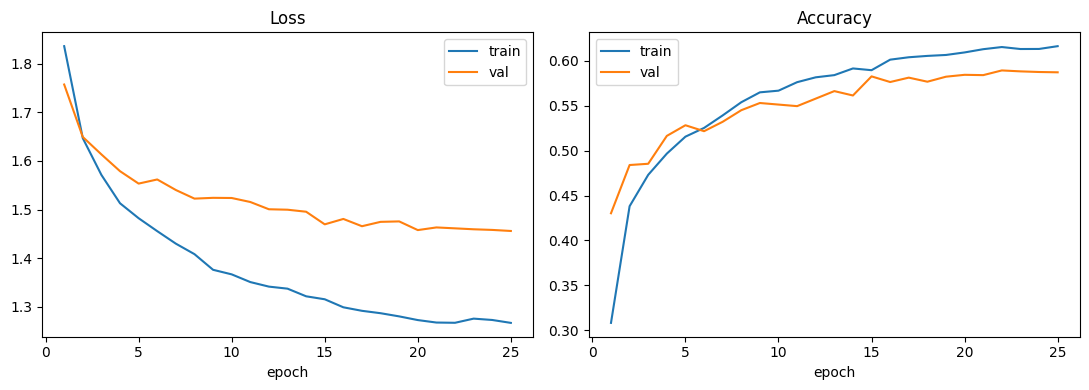

In [27]:
from dataclasses import asdict
from emotion.src.evaluate import plot_training_curves
fig = plot_training_curves(asdict(history),
                           save_path=C.REPORTS_DIR / 'training_curves.png')
plt.show()

## 7. Evaluate on the public test set

In [28]:
from emotion.src.model import load_checkpoint
from emotion.src.evaluate import collect_predictions, metrics_report, plot_confusion_matrix

best = load_checkpoint(C.MODELS_DIR / 'mobilenetv2_best.pth')
y_true, y_pred, y_prob = collect_predictions(best, test_loader)
report = metrics_report(y_true, y_pred)
print('Test accuracy   :', round(report['accuracy'],   4))
print('Test macro-F1   :', round(report['macro_f1'],   4))
print('Test weighted-F1:', round(report['weighted_f1'],4))
print()
print(report['classification_report'])

Test accuracy   : 0.5823
Test macro-F1   : 0.5353
Test weighted-F1: 0.5827

              precision    recall  f1-score   support

       angry     0.5057    0.4603    0.4820       958
     disgust     0.2269    0.7297    0.3462       111
        fear     0.4666    0.2998    0.3650      1024
       happy     0.8447    0.7818    0.8121      1774
     neutral     0.4968    0.6253    0.5537      1233
         sad     0.4775    0.4755    0.4765      1247
    surprise     0.7018    0.7220    0.7117       831

    accuracy                         0.5823      7178
   macro avg     0.5314    0.5849    0.5353      7178
weighted avg     0.5959    0.5823    0.5827      7178



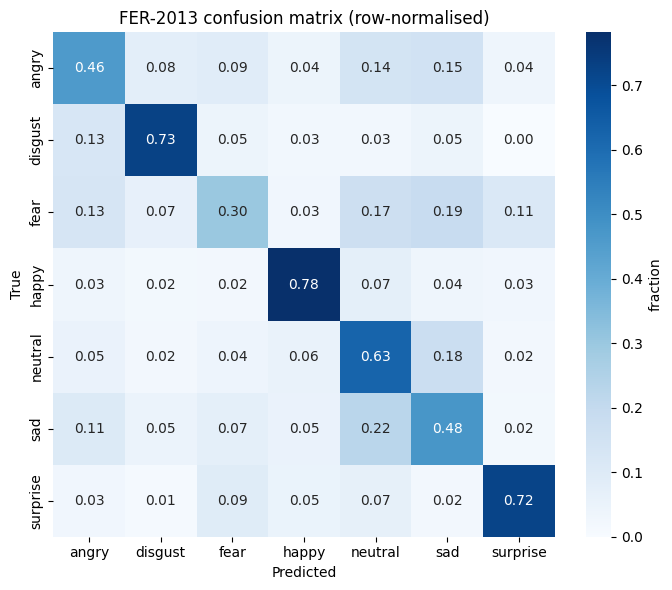

In [29]:
fig = plot_confusion_matrix(report['confusion_matrix'],
                            save_path=C.REPORTS_DIR / 'confusion_matrix.png',
                            normalize=True)
plt.show()

# Also dump raw numbers as JSON for the report.
import json
with open(C.REPORTS_DIR / 'test_metrics.json', 'w') as f:
    json.dump({k: v for k, v in report.items() if k != 'classification_report'}, f, indent=2)

**Discussion bullets for the report:**
- Expect ~65–70% test accuracy on FER-2013 with this recipe; SOTA is ~75% so this is a competitive baseline.
- Look at the confusion matrix for the two famous confusion pairs: **fear↔surprise** and **sad↔neutral**. Both are linguistically and visually overlapping in FER-2013.
- Per-class F1 for `disgust` is the key metric — without class weights it tends to ~0; with them you should see a meaningful number (the report can cite both ablations if time permits).

## 8. Smoke-test the predictor (the UI's entrypoint)

In [30]:
from emotion.src.predict import EmotionPredictor
import numpy as np
from PIL import Image

predictor = EmotionPredictor(C.MODELS_DIR / 'mobilenetv2_best.pth', input_is_bgr=False)

# Grab one test image, run it through the public API, print result.
sample_dir = C.TEST_DIR / 'happy'
sample_path = sample_dir / sorted(os.listdir(sample_dir))[0]
img = Image.open(sample_path)
result = predictor.predict(np.array(img.convert('RGB')))
print('file       :', sample_path.name)
print('true class : happy')
print('prediction :', result)

file       : PrivateTest_10077120.jpg
true class : happy
prediction : {'label': 'happy', 'confidence': 0.8723312020301819, 'all_scores': {'angry': 0.004337373189628124, 'disgust': 0.07610265910625458, 'fear': 0.00744550721719861, 'happy': 0.8723312020301819, 'neutral': 0.024210834875702858, 'sad': 0.007398776710033417, 'surprise': 0.008173656649887562}}


## 9. Hand-off checklist
- `models/mobilenetv2_best.pth` — give to UI teammate (or share via Drive).
- `emotion/src/predict.py` — the UI imports `EmotionPredictor`; nothing else needed.
- `reports/confusion_matrix.png`, `training_curves.png`, `class_distribution.png`, `sample_grid.png` — drop into the group report.
- `reports/test_metrics.json` — numbers for the Results section.